In [4]:
import langchain
from langchain.chat_models import init_chat_model
import os
from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.tools import tool

In [4]:
load_dotenv()  # Load environment variables from .env file
os.environ["OPENROUTER_API_KEY"] = os.getenv("OPENROUTER_API_KEY")

In [5]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [4]:
model = init_chat_model(model="cohere/north-mini-code:free",
                        model_provider="openrouter",
                         temperature=0.7)

In [5]:
from langchain_groq import ChatGroq



llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)



In [6]:
llm2= ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

In [7]:
llm3 = init_chat_model(model="openai/gpt-oss-20b",
                        model_provider="groq")

In [6]:
ollam_model = init_chat_model(model="nemotron-3-nano:4b",
                             model_provider="ollama")

In [7]:
for response in ollam_model.stream("Write a python function to calculate the factorial of a number"):
    print(response.text, end="")

To calculate the factorial of a non-negative integer, we can use an iterative approach for efficiency and to avoid recursion limits. The factorial of a number `n` (denoted as `n!`) is the product of all positive integers up to `n`. The base cases are `0! = 1` and `1! = 1`.

Here's the Python function implementing this:

```python
def factorial(n):
    if n < 0:
        raise ValueError("Factorial is not defined for negative numbers")
    result = 1
    for i in range(1, n + 1):
        result *= i
    return result
```

**Explanation:**
- **Input validation:** The function checks if `n` is negative and raises a `ValueError` if so.
- **Base case:** If `n` is 0, the loop doesn't run (since `range(1, 0+1)` is empty), and `result` remains 1 (which is correct for `0!`).
- **Iterative calculation:** For `n > 0`, the loop multiplies `result` by each integer from 1 to `n` (inclusive).

**Example usage:**
```python
print(factorial(0))  # Output: 1
print(factorial(5))  # Output: 120 (5*4*3*2*1)


In [25]:
for response in llm3.stream("who is chief minister of odisha india?"):
    print(response.text, end="")

The current Chief Minister of Odisha (India) is **Naveen Patnaik**. He has been in office since 2000, representing the Biju Janata Dal (BJD), and was re‑elected in the most recent state elections.

In [8]:
responses = ollam_model.batch([
    "Why do parrots have colorful feathers?",
    "How do airplanes fly?",
    "What is quantum computing?"
])
for response in responses:
    print(response.text)

Parrots' vibrant, iridescent feathers are primarily a result of **structural coloration** – not just pigments (like dyes). This means the color comes from microscopic hair-like structures on the feather shafts (called *paraxial cells*), which scatter and refract light in specific ways. This is *not* the same as carotenoids (from food) or pigments (like in roses). Here's why this adaptation evolved:

1.  **Mate Attraction & Reproduction:**  
    - Bright colors are a signal of health, genetic fitness, and age. A parrot with vibrant, well-developed iridescent feathers is often considered more attractive to potential mates (like a peacock's tail, but more dynamic).
    - Helps individuals find partners quickly, increasing mating success.

2.  **Species Identification & Territorial Defense:**  
    - Each parrot species has a unique color pattern and color intensity. If a female hatches, recognizing her species is critical for survival (males provide protection).
    - Bright colors signal

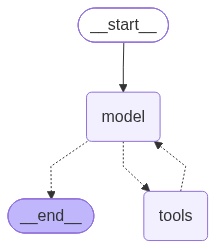

In [51]:
@tool
def get_weather(city:str)-> str:
    """Get the weather for a city. which wil bw asked by user"""
    return f"The weather in {city} is sunny."

agent=create_agent(
    model= model,
    tools=[get_weather],
    system_prompt="You are a helpful assistant."
)
agent

In [40]:
from langchain.messages import HumanMessage
for res in agent.stream(HumanMessage(content="What is the weather in New York City?")):
    print(res["model"]["messages"], end="")

[AIMessage(content='Sure thing! How can I help you today?', additional_kwargs={'reasoning_content': "The user hasn't asked anything yet. We need to respond as a helpful assistant. Probably we should ask what they need."}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 125, 'total_tokens': 169, 'completion_time': 0.046425793, 'completion_tokens_details': {'reasoning_tokens': 25}, 'prompt_time': 0.007200541, 'prompt_tokens_details': None, 'queue_time': 0.210432829, 'total_time': 0.053626334}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_a12402de73', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09207-ec3d-7b32-b947-af6637b8a4ff-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 125, 'output_tokens': 44, 'total_tokens': 169, 'output_token_details': {'reasoning': 25}})]

In [54]:
agent.invoke({"role": "user", "content": "What is the weather in New York City?"})

{'messages': [AIMessage(content="Hello! I'm here to help you. I have access to a weather function that can get current weather information for any city you're interested in. \n\nWhat can I help you with today? If you're looking for weather information for a specific city, just let me know the city name and I'll get that for you!", additional_kwargs={'reasoning_content': 'The user has just said "You are a helpful assistant." This seems like a general statement rather than a specific request. They haven\'t asked me to do anything in particular or asked a question. \n\nLooking at the available functions, I only have access to a weather function that gets weather information for a city. Since the user hasn\'t asked for weather information, I don\'t need to use any functions.\n\nI should respond in a helpful way to the user\'s statement, but since it\'s just a general statement, I should probably ask what they need help with or if they have a specific request for me.', 'reasoning_details': 

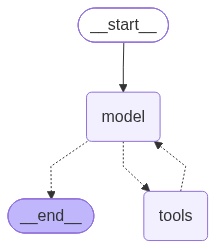

In [59]:
from langchain.agents import create_agent

def get_weather(city:str)-> str:
    """Get the weather for a city."""
    return f"The weather in {city} is sunny."

agent=create_agent(
    model="groq:openai/gpt-oss-20b",
    tools=[get_weather],
    system_prompt="You are a helpful assistant."
)
agent

In [60]:
### run the agent
response=agent.invoke({"messages":[{"role":"user","content":"What is the weather like in New York?"}]})

In [68]:
response1 = agent.invoke({"messages": [HumanMessage(content="What is the weather like in New York?")]})

In [69]:
response1

{'messages': [HumanMessage(content='What is the weather like in New York?', additional_kwargs={}, response_metadata={}, id='87892563-0640-4185-acef-0c66a0214180'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call get_weather function.', 'tool_calls': [{'id': 'fc_4bf6262c-3fff-41be-b315-1a5f0dcb3e31', 'function': {'arguments': '{"city":"New York"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 138, 'total_tokens': 171, 'completion_time': 0.036299484, 'completion_tokens_details': {'reasoning_tokens': 9}, 'prompt_time': 0.006629068, 'prompt_tokens_details': None, 'queue_time': 0.401573719, 'total_time': 0.042928552}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_d23c14756c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0921b-6b76-7ab0-bdd7-4983f66cd218-0', tool_calls=[{'name': 'get_weather'

In [64]:
response

{'messages': [HumanMessage(content='What is the weather like in New York?', additional_kwargs={}, response_metadata={}, id='e516d3cb-42de-46d3-bb09-7fca1455bbad'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call function get_weather with city "New York".', 'tool_calls': [{'id': 'fc_63a1b9ba-da70-49c5-9bb8-395a97df94a9', 'function': {'arguments': '{"city":"New York"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 138, 'total_tokens': 176, 'completion_time': 0.038910786, 'completion_tokens_details': {'reasoning_tokens': 14}, 'prompt_time': 0.007651711, 'prompt_tokens_details': None, 'queue_time': 0.333158457, 'total_time': 0.046562497}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_66f3850a1a', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09214-c726-7052-a6e7-0756ef49f801-0', tool_calls=[

In [65]:
agent.invoke({"messages":"What is the weather in New Yourk"})

{'messages': [HumanMessage(content='What is the weather in New Yourk', additional_kwargs={}, response_metadata={}, id='ee214d15-34c1-4a60-8854-924708f36f35'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "What is the weather in New Yourk". They misspelled "New York". We need to get weather for New York. Use get_weather function.', 'tool_calls': [{'id': 'fc_ff23ff35-4903-484c-9559-cf494ee9c1b5', 'function': {'arguments': '{"city":"New York"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 137, 'total_tokens': 197, 'completion_time': 0.06237578, 'completion_tokens_details': {'reasoning_tokens': 36}, 'prompt_time': 0.006673182, 'prompt_tokens_details': None, 'queue_time': 0.401305547, 'total_time': 0.069048962}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_d23c14756c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': '

In [70]:
@tool
def get_weather(location:str)->str:
    """Get the weather at a location"""
    return f"It's sunny in {location}"


model_with_tools=model.bind_tools([get_weather])

In [71]:
response = model_with_tools.invoke("What's the weather like in Boston?")
print(response)
for tool_call in response.tool_calls:
    # View tool calls made by the model
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

content='' additional_kwargs={'reasoning_content': 'The user is asking for the weather in Boston. I have access to a get_weather function that takes a location parameter. The user has provided "Boston" as the location, so I have all the required parameters to make the function call.', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'The user is asking for the weather in Boston. I have access to a get_weather function that takes a location parameter. The user has provided "Boston" as the location, so I have all the required parameters to make the function call.'}]} response_metadata={'model_name': 'cohere/north-mini-code:free', 'id': 'gen-1789157934-fxo18Jo8LZiM3qDAslmw', 'created': 1789157934, 'object': 'chat.completion', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'openrouter', 'cost': 0.0, 'cost_details': {'upstream_inference_completions_cost': 0.0, 'upstream_inference_prompt_cost': 0.0, 'upstream_inference_cost': 0.0}}

In [76]:
# Step 1: Model generates tool calls
messages = [{"role": "user", "content": "What's the weather in Boston?"}]
ai_msg = model_with_tools.invoke(messages)
print("AI msg =====>", ai_msg)
messages.append(ai_msg)

# Step 2: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
    # Execute the tool with the generated arguments
    print("tool call ======>", tool_call)
    tool_result = get_weather.invoke(tool_call)
    print("tool result ======>", tool_result)
    messages.append(tool_result)
    print("message =====>",messages)

# Step 3: Pass results back to model for final response
final_response = model_with_tools.invoke(messages)
print(final_response.text)
# "The current weather in Boston is 72°F and sunny."

AI msg =====> content='' additional_kwargs={'reasoning_content': 'The user is asking for the weather in Boston. I have access to a get_weather function that takes a location parameter. The user has specified "Boston" as the location, so I have all the required parameters to make the function call.', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'The user is asking for the weather in Boston. I have access to a get_weather function that takes a location parameter. The user has specified "Boston" as the location, so I have all the required parameters to make the function call.'}]} response_metadata={'model_name': 'cohere/north-mini-code:free', 'id': 'gen-1789158474-JVmYO3PUUfMHHNWYPO30', 'created': 1789158474, 'object': 'chat.completion', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'openrouter', 'cost': 0.0, 'cost_details': {'upstream_inference_completions_cost': 0.0, 'upstream_inference_prompt_cost': 0.0, 'upstream_infere

In [2]:
from langgraph.graph import START,END,StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from langgraph.graph import add_messages
from typing import TypedDict, Annotated


c:\Users\Sangram Mishra\Desktop\ADK\.venv\Lib\site-packages\langchain_core\utils\pydantic.py:42: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


In [20]:
from dotenv import load_dotenv
load_dotenv()



True

In [21]:
from langchain_ollama import ChatOllama
llm = ChatOllama(
    model= "nemotron-3-nano:4b"
)

In [22]:
from langchain.messages import HumanMessage

In [27]:

res = llm.invoke([HumanMessage(content="why earth rotate")])

In [29]:
print(res.content)

Earth rotates due to **gravity pulling it into a spinning state during its formation**, amplified by **impacts from planetesimals** (small rocks or debris) in the early solar system. Here's a simple breakdown:

1. **Formation with a Spin**: When Earth formed ~4.5 billion years ago, it didn't form spinning—it was gradually pulled by gravity, but some collisions with other debris added momentum (angular momentum) to it, causing it to spin.
2. **Impact-Driven Spinning**: Smaller rocks (planetesimals) bombarding Earth during formation would've added rotational energy. However, most of that energy was lost when the debris slid off Earth's surface or merged into orbit, slowing the rotation over time.
3. **Result: A Slow Spin**: Today, Earth spins at a relatively moderate rate because most "spin energy" was lost during this violent process. This gives us our 24-hour day/night cycle.

**Why it’s not due to other forces**:  
- ❌ *Not the Sun*: Earth doesn’t "spin because of the Sun's gravity." 

In [7]:
from langchain.tools import tool

In [59]:
class State(TypedDict):
    messages : Annotated[list,add_messages]

In [60]:

def get_weather(city:str)->str:
    """this fuction should return weather of asking city"""
    city = city.capitalize()
    details = {
        "Puri" :"its cloudy and rainy today"
    }
    return details.get(city,"weather not available")

In [61]:
get_weather("puri")

'its cloudy and rainy today'

In [62]:

def calculator(a:int,b:int)->int:
    """this function will act as a calculatr for addition
    arg: a 
    arg: b
    return a+b """
    return a+b

In [105]:
graph = StateGraph(State)

In [106]:
tools = [get_weather,calculator]
llm_tool = llm.bind_tools(tools)

In [107]:
def tool_calling_llm(state:State):
    return {"messages":[llm_tool.invoke(state["messages"])]}

In [108]:

tools = ToolNode(tools)

In [109]:
graph.add_node("llm_node",tool_calling_llm)
graph.add_node("tools",tools)
graph.add_edge(START,"llm_node")
graph.add_conditional_edges("llm_node",tools_condition)
graph.add_edge("tools","llm_node")

In [111]:
APP = graph.compile()

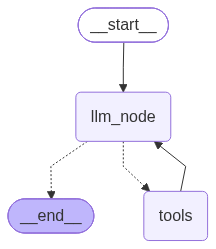

In [112]:
APP

In [116]:
response = APP.invoke({"messages":"What is 2+2 and what is the weathe in newyork and 4+5"})

In [1]:
print(response["messages"][-1].content)

NameError: name 'response' is not defined

In [103]:
response

{'messages': [HumanMessage(content='What is 2+2 and what is the weathe in puri and 4+5', additional_kwargs={}, response_metadata={}, id='9fe3d818-8d8f-49e7-9149-b0921f06c106'),
  AIMessage(content='\n', additional_kwargs={}, response_metadata={'model': 'nemotron-3-nano:4b', 'created_at': '2026-09-24T19:17:08.1544072Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6483112000, 'load_duration': 15374800, 'prompt_eval_count': 439, 'prompt_eval_duration': 480692000, 'eval_count': 286, 'eval_duration': 5961057000, 'logprobs': None, 'model_name': 'nemotron-3-nano:4b', 'model_provider': 'ollama'}, id='lc_run--01a0d4d9-8a63-7fc1-afa0-23bf697715c5-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Puri'}, 'id': '8802bdf4-3bad-4e07-8215-5126a20c7235', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 439, 'output_tokens': 286, 'total_tokens': 725}),
  ToolMessage(content='its cloudy and rainy today', name='get_weather', id='76ff0421-d96f-4a30-a05e-8380